<a href="https://colab.research.google.com/github/evelyn450511/ModelosEstocasticos-EDTS-/blob/main/AlgoritmoCM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmo para simular una Cadena de Markov

*Evelyn Daniela Tapia Serrano*

Se presenta el modelado de una CMTD aplicada a un juego de tablero circular.
El objetivo es observar cómo la cadena converge a una **distribución estacionaria** a largo plazo.

---
## Escenario: El Tablero de Colores
* **Estados:** Un tablero circular con 4 colores (0, 1, 2, 3).
* **Movimiento:** Se lanzan 2 monedas. El número de caras determina el avance:
  * 0 caras ($P=0.25$): Permanece en el sitio.
  * 1 cara ($P=0.50$): Avanza 1 casilla.
  * 2 caras ($P=0.25$): Avanza 2 casillas.

## Código 1: Simulación Automatizada (Reglas del Tablero)
En esta versión, las reglas de transición están predefinidas según la probabilidad de las monedas.
La matriz de transición $P$ se genera automáticamente como una matriz **doblemente estocástica**, lo que garantiza que, a largo plazo, la probabilidad de estar en cualquier color sea uniforme ($0.25$).

**Características:**
* Configuración automática de la matriz $P$.
* Distribución inicial ($\alpha$) uniforme.
* Simulación de $N$ pasos para comprobar convergencia.

In [1]:
import numpy as np

# Definición de parámetros del tablero
n_pasos = 10000  # Número de pasos suficiente para ver la convergencia
n_estados = 4

# Distribución inicial uniforme
alpha = np.array([0.25, 0.25, 0.25, 0.25])

# Construcción de la Matriz de Transición P

P = np.zeros((n_estados, n_estados))
for i in range(n_estados):
    P[i, (i + 0) % 4] = 0.25
    P[i, (i + 1) % 4] = 0.50
    P[i, (i + 2) % 4] = 0.25

print("Matriz de Transición P:")
print(P)
print("-" * 30)

def simular(alpha, P, n, num_estados):
    estados = np.arange(num_estados)
    X = [0] * (n + 1)
    # Estado inicial basado en alpha
    X[0] = np.random.choice(estados, p=alpha)

    for i in range(1, n + 1):
        estado_actual = X[i - 1]
        probabilidades = P[estado_actual]
        X[i] = np.random.choice(estados, p=probabilidades)

    return X

# Ejecutar simulación
resultado = simular(alpha, P, n_pasos, n_estados)

# Comprobación de probabilidades a largo plazo
counts = np.bincount(resultado)
probabilidades_finales = counts / len(resultado)

print(f"Frecuencias tras {n_pasos} pasos:")
for i, prob in enumerate(probabilidades_finales):
    print(f"Color {i}: {prob:.4f}")

print("\nConclusión: Como las probabilidades son cercanas a 0.25,se cumple la distribución uniforme a largo plazo.")

Matriz de Transición P:
[[0.25 0.5  0.25 0.  ]
 [0.   0.25 0.5  0.25]
 [0.25 0.   0.25 0.5 ]
 [0.5  0.25 0.   0.25]]
------------------------------
Frecuencias tras 10000 pasos:
Color 0: 0.2537
Color 1: 0.2489
Color 2: 0.2465
Color 3: 0.2510

Conclusión: Como las probabilidades son cercanas a 0.25,se cumple la distribución uniforme a largo plazo.


## Código 2: Simulación Personalizada (Entrada de Usuario)
Esta versión permite al usuario definir cualquier configuración de CMTD.

**Validaciones incluidas:**
1. **Suma de Fila:** El programa verifica que cada fila de la matriz $P$ sume exactamente $1$.
2. **Dimensión:** Asegura que la matriz sea cuadrada y acorde al número de estados.
3. **Análisis Empírico:** Calcula las frecuencias relativas finales para comparar con la teoría.

In [2]:


def simular_cmtd(alpha, P, n):
    num_estados = len(alpha)
    estados = np.arange(num_estados)
    X = np.zeros(n + 1, dtype=int)

    # Estado inicial
    X[0] = np.random.choice(estados, p=alpha)

    # Simulación de pasos
    for i in range(1, n + 1):
        estado_actual = X[i - 1]
        p_transicion = P[estado_actual]
        X[i] = np.random.choice(estados, p=p_transicion)

    return X

# Configuración inicial
n_estados = int(input("Número de colores/estados en el tablero: "))
n_pasos = int(input("Número de pasos para la simulación: "))

# Distribución inicial (alpha)
print(f"\n probabilidades iniciales: ")
alpha_list = []
for i in range(n_estados):
    prob = float(input(f"P({i}): "))
    alpha_list.append(prob)
alpha = np.array(alpha_list)

# Ingreso de la Matriz de Transición P
print(f"\n filas de la matriz de transición:")
P_list = []
for i in range(n_estados):
    while True:
        fila = list(map(float, input(f"Fila {i}: ").split()))
        if len(fila) != n_estados:
            print(f"Error: La fila debe tener {n_estados} elementos.")
        elif abs(sum(fila) - 1.0) > 1e-6:
            print(f"Error: La fila debe sumar 1 (suma actual: {sum(fila)}).")
        else:
            P_list.append(fila)
            break
P = np.array(P_list)

resultado = simular_cmtd(alpha, P, n_pasos)

# Análisis de resultados
counts = np.bincount(resultado, minlength=n_estados)
prob_empirica = counts / len(resultado)

print("\n" + "="*30)
print("RESULTADOS DE LA SIMULACIÓN")
print("="*30)
for i in range(n_estados):
    print(f"Estado {i} (Color {i}): {prob_empirica[i]:.4f}")


if np.allclose(P.sum(axis=0), 1.0):
    print("\nNota: Tu matriz es doblemente estocástica, por lo que la probabilidad uniforme es el resultado esperado.")

Número de colores/estados en el tablero: 4
Número de pasos para la simulación: 1000

 probabilidades iniciales: 
P(0): 0.25
P(1): 0.25
P(2): 0.25
P(3): 0.25

 filas de la matriz de transición:
Fila 0: 1 0 0 0
Fila 1: 0 0.25 0.25 0.5
Fila 2: 0 0 1 0
Fila 3: 0.25 0.25 0.25 0.25 

RESULTADOS DE LA SIMULACIÓN
Estado 0 (Color 0): 0.0000
Estado 1 (Color 1): 0.0000
Estado 2 (Color 2): 1.0000
Estado 3 (Color 3): 0.0000


## Gráfica
Para comprobar que a largo plazo los cuatro colores tienen igual probabilidad, se grafico la **probabilidad acumulada** de cada estado a medida que transcurren los pasos.

Si la teoría es correcta, las líneas de los 4 estados deberían converger hacia el valor de **0.25** (distribución uniforme).

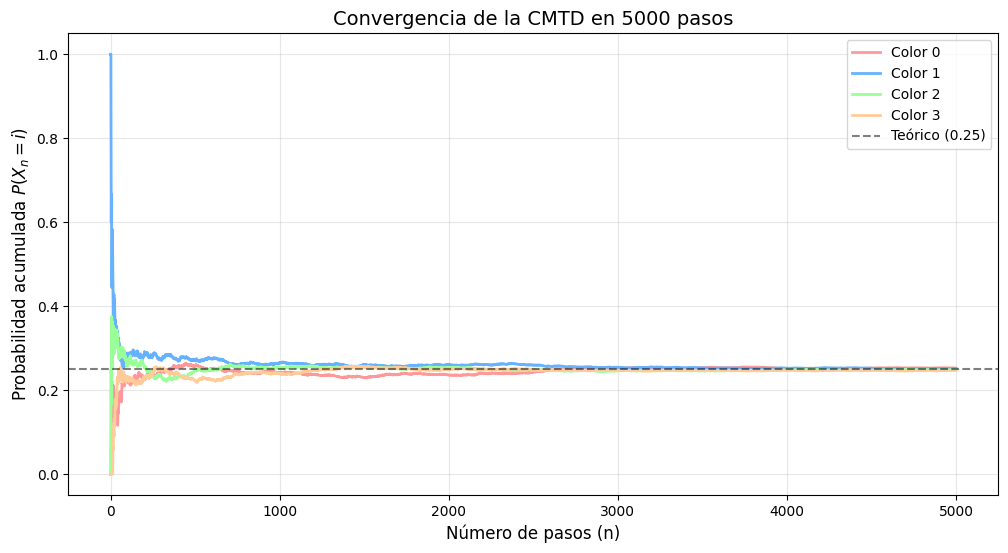

Probabilidades finales estimadas: [0.2526 0.2516 0.2488 0.247 ]


In [3]:

import matplotlib.pyplot as plt

# Configuración de la CMTD (Tablero Circular)
n_estados = 4
n_pasos = 5000
alpha = np.array([0.25, 0.25, 0.25, 0.25])
P = np.array([
    [0.25, 0.50, 0.25, 0.00],
    [0.00, 0.25, 0.50, 0.25],
    [0.25, 0.00, 0.25, 0.50],
    [0.50, 0.25, 0.00, 0.25]
])

# Simulación guardando la evolución de frecuencias
def simular_con_historia(alpha, P, n):
    estados = np.arange(len(alpha))
    X = [np.random.choice(estados, p=alpha)]
    historial_probs = np.zeros((n, len(alpha)))
    conteos = np.zeros(len(alpha))
    for i in range(n):
        estado_actual = X[-1]
        siguiente = np.random.choice(estados, p=P[estado_actual])
        X.append(siguiente)
        conteos[siguiente] += 1
        historial_probs[i] = conteos / (i + 1)

    return historial_probs
evolucion = simular_con_historia(alpha, P, n_pasos)
plt.figure(figsize=(12, 6))
colores_grafica = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for i in range(n_estados):
    plt.plot(evolucion[:, i], label=f'Color {i}', color=colores_grafica[i], lw=2)
plt.axhline(y=0.25, color='black', linestyle='--', alpha=0.5, label='Teórico (0.25)')
plt.title(f'Convergencia de la CMTD en {n_pasos} pasos', fontsize=14)
plt.xlabel('Número de pasos (n)', fontsize=12)
plt.ylabel('Probabilidad acumulada $P(X_n = i)$', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print(f"Probabilidades finales estimadas: {evolucion[-1]}")